## Intervalos de confianza
Otra forma de presentar el resultado de una estimación es ya no con un solo valor posible de lo que se desea estimar, sino con un conjunto de valores probables. Esto se puede hacer a través de los intervalos de confianza. Además, son una forma de expresar el error potencial en una estimación muestral.

Recordemos la definición de un intervalo de confianza.
> ### Intervalo de confianza
> Sea una muestra aleatoria $Y_1, ..., Y_n$, sean $T_L(\textbf{Y})=T_L(Y_1, ..., Y_n)$ y $T_U(\textbf{Y})$ dos funciones de las observaciones tal que
> $$ 
     \mathbb{P}[T_L(\textbf{Y})\le\theta\le T_U(\textbf{Y})]=1-\alpha\text{,}$$
> para todos los valores posibles de $\theta$.
> Una vez que los datos $\mathbf{Y}=\mathbf{y}$ son observados, el intervalo $[T_L(\textbf{y}),T_U(\textbf{y})]$ es llamado un **_intervalo de confianza_** del $100(1-\alpha)\%$ para $\theta$, con límites de confianza inferior y superior $T_L(\textbf{y})$ y $T_U(\textbf{y})$ respectivamente. La probabilidad $1-\alpha$, llamada **_nivel de confianza_**, usualmente se escoge cercana a 1, e.g. $0.95$ o $0.99$. La probabilidad correspondiente $\alpha$ es una **_probabilidad de error_**.

Otra manera de definirlo es como sigue

_Notación_: Decimos que $I_n\subset\mathbb{R}$ es un intervalo aleatorio si existen funciones $a$ y $b$ tales que 
$$
     I_n=[a(X_1,...,X_n), b(X_1,...,X_n)]\text{,}   
$$
> ### Definición
> Sea $\mathcal{F}_\theta=\{f_\theta:\theta\in\Theta\}$ & $\alpha\in(0,1)$. Decimos que un intervalo aleatorio $I_n$ es un intervalo de confianza con cobertura $1-\alpha$ si
> $$
    \mathbb{P}[\theta\in I_n]\ge1-\alpha\quad\text{y}\quad\mathbb{P}[\theta\notin I_n]\le\alpha\quad\forall\theta\in\Theta\text{.}
 $$
Nos interesa el caso $X_1, ..., X_n\overset{i.i.d.}{\sim}f_\theta,\ I_n=I_n(X_1, ..., X_n)$.

# Observación
## $\theta$ es fijo y $I_n$ es aleatorio (hasta la observación de la muestra). La probabilidad asociada a $\alpha$ es **_a priori_**.

Es por esto que existe una distinción sutil entre "confianza" y "probabilidad". Una vez que hemos observado los datos, un intervalo de confianza contiene **o no** al parámetro. Una probabilidad como $0.95$ aplica al intervalo aleatorio $[T_L(\textbf{Y}),T_U(\textbf{Y})]$, con extremos que son variables aleatorias, _antes_ de que observemos los datos.

Ustedes ya han visto intervalos de confianza asintóticos, haciendo uso del teorema del límite central o la normalidad asintótica de los estimadores máximo verosímil.
> ### Definición
> Sea $\mathcal{F}=\{f_\theta:\theta\in\Theta\}$ & $\alpha\in(0,1)$. Decimos que una familia de intervalos $\{I_n\}_{n\ge1}$ es un intervalo de confianza asintótico de cobertura $1-\alpha$ si
> $$
    \lim_{n\to\infty}\mathbb{P}[\theta\in I_n]\ge1-\alpha\text{,}\quad \forall\theta\in\Theta\text{.}
 $$

### Ejemplo
Sean $X_1,...,X_n\overset{i.i.d.}{\sim}\text{N}(\mu,1)$ con $\mu\in\mathbb{R}$ y $\alpha\in(0,1)$. Podemos definir el intervalo aleatorio 
$$
    I_n^{(\alpha)}=\left[\hat{\mu}_{ML}-Q^{-1}\left(\alpha/2\right)/\sqrt{n},\  \hat{\mu}_{ML}+Q^{-1}\left(\alpha/2\right)/\sqrt{n}\right]
$$
donde $Q(x)=\mathbb{P}[\text{N}(0,1)>x]$.

_Obs._: el intervalo mide $\frac{1}{\sqrt{n}}$, no tiene longitud constante.

Tenemos que 
$$
\mathbb{P}[\mu\in I_n^{(\alpha)}]=\mathbb{P}\left[\hat{\mu}_{ML}-Q^{-1}\left(\alpha/2\right)/\sqrt{n}\le\mu\le\  \hat{\mu}_{ML}+Q^{-1}\left(\alpha/2\right)/\sqrt{n}\right]=\mathbb{P}\left[|\hat{\mu}_{ML}-\mu|\le\frac{Q^{-1}\left(\frac{\alpha}{2}\right)}{\sqrt{n}}\right]
$$
y sabemos que
$$
    \hat{\mu}_{ML}-\mu=\bar{X}-\mu\sim\text{N}\left(0,\frac{1}{n}\right)\text{,}
$$
es decir,
$$
    \hat{\mu}_{ML}-\mu\overset{d}{\sim}\frac{Z}{\sqrt{n}}\text{, con}\quad Z\sim\text{N}(0,1)\text{.}
$$
Por igualdad en distribución 
$$
    \mathbb{P}\left[\mu\in I_n^{(\alpha)}\right]=\mathbb{P}\left[\frac{|Z|}{\sqrt{n}}\le\frac{Q^{-1}\left(\frac{\alpha}{2}\right)}{\sqrt{n}}\right]=\mathbb{P}\left[|Z|\le Q^{-1}\left(\frac{\alpha}{2}\right)\right]=1-2Q\left(Q^{-1}\left(\frac{\alpha}{2}\right)\right)=1-\alpha.
$$

### Ejemplo
Tener un "$95\%$ de confianza"  significa que si el método de construcción del intervalo de confianza fuera utilizado para analizar un número gigantesco de diferentes data sets (estadísticamente equivalentes), entonces, a la larga un $95\%$ de los intervalos de confianza contendrían el valor verdadero del parámetro. Como es ya tradición ancestral, utilicemos simulación para poder visualizarlo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x_l = np.empty(100)
x_u = np.empty(100)
n = 15
offset = (1/np.sqrt(n))*1.960
for i in range(0,100):
    x_m = np.mean(np.random.normal(100,1,n))
    x_l[i] = x_m-offset
    x_u[i] = x_m+offset

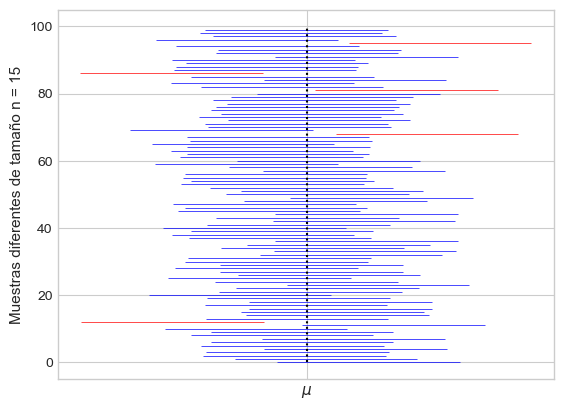

In [6]:
plt.style.use('seaborn-v0_8-whitegrid')
y = np.linspace(0,100,100)
for i in range(0,100):
    if 100<x_l[i] or x_u[i]<100:
        plt.hlines(i, x_l[i], x_u[i], color = 'red', linewidth = 0.5)
    else:
        plt.hlines(i, x_l[i], x_u[i], color = 'blue', linewidth = 0.5)
plt.ylabel(f'Muestras diferentes de tamaño n = {n:.0f}', fontsize = 11)
plt.xticks((100,), [r'$\mu$'], fontsize = 11)
plt.vlines(100,0,100, linestyles = 'dotted', colors = 'k')
plt.show()

### Ejercicio
Para una distribución hipotética normal de parámetros $\mu = 50$ y $\sigma = 1.5$ que da lugar a una muestra $X_1, ..., X_n$ (utiliza el $n$ de tu elección) comprueba a través de simulación que un $95\%$ de los intervalos de confianza bootstrap de cobertura de $0.95$ para $\sigma$ contienen el verdadero parámetro $\sigma$.

## Usar una cantidad pivotal para inducir un intervalo de confianza.
Muchas veces podemos encontrar los límites de confianza $T_L(\textbf{Y})$ y $T_U(\textbf{Y})$ utilizando la distribución muestral de un estadístico $T(\textbf{Y})$ que es un buen estimador de $\theta$. Si $T(\textbf{Y})\sim\text{N}(\theta,\sigma_T^2)$, entonces la variable aleatoria estandarizada 
$$
    \frac{T(\textbf{Y})-\theta}{\sigma_T}\sim\text{N}(0,1)\text{.}
$$
Este cociente es función de $\mathbf{Y}$ y $\theta$ pero tiene una distribución que no depende de $\theta$ y se le conoce como **_cantidad pivotal_**.

Dado que $95\%$ de la distribución normal estándar se encuentra entre $-1.96$ y $1.96$,
$$
    \mathbb{P}\left[-1.96\le\frac{T(\mathbf{Y}-\theta)}{\sigma_T}\le1.96\right]=0.95
$$
$$
    \iff
$$
$$
    \mathbb{P}\left[T(\mathbf{Y})-1.96\sigma_T\le\theta\le T(\textbf{Y})+1.96\sigma_T\right]=0.95\text{.}
$$
Una vez que observemos $\textbf{y}$, el intervalo con extremos
$$
    T_L(\textbf{y})=T(\textbf{y})-1.96\sigma_T
$$
y
$$
    T_U(\textbf{y})=T(\textbf{y})+1.96\sigma_T
$$
es un intervalo de $95\%$ de confianza para $\theta$.

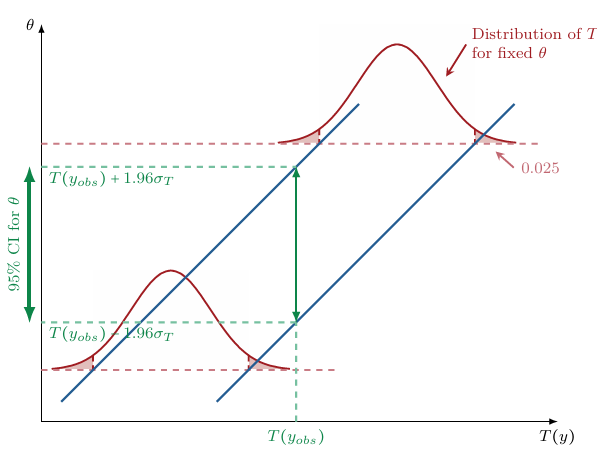

En varios casos ya vistos (e.g.teorema del lím. central, normalidad asintótica de los MLE) es usualmente posible formar una cantidad pivotal $(\hat{\theta}-\theta)/\sigma_{\hat{\theta}}$, utilizando un estimador $\hat{\theta}$ de $\theta$ que tenga error estándar $\sigma_{\hat{\theta}}$.

Sea $z_a$ el cuantil de una distr. normal estándar para una **probabilidad de cola** igual a $a$, e.g. $z_{0.025}=1.96$ y $z_{0.005}=2.58$. Luego, para un nivel de confianza $1-\alpha$, el intervalo de confianza utiliza cuantiles con probabilidades de cola igual a $\alpha/2$ y tiene la siguiente forma familiar
$$
    \hat{\theta}\pm z_{\alpha/2}\sigma_{\hat{\theta}}.
$$

- Al incrementarse el nivel de confianza el intervalo se hace más agranda.
- Al crecer $n$, el error estándar decrece, por lo que el intervalo se achica.

En el caso de la media poblacional $\theta=\mu$ el intervalo se construye como $\bar{y}\pm1.96\sigma/\sqrt{n}$ tal que
$$
    \mathbb{P}\left[-1.96\le\frac{\bar{Y}-mu}{\sigma/\sqrt{n}}\le1.96\right]=\mathbb{P}\left[\bar{Y}-1.96\frac{\sigma}{\sqrt{n}}\le\mu\le\bar{Y}+1.96\frac{\sigma}{\sqrt{n}}\right]\to0.95\text{.}
$$
**Sin embargo en este intervalo se está utilizando $\sigma$.**

## Determinar el tamaño de muestra antes de recolectar los datos.
Dado que el margen de error en un intervalo de confianza depende del error estándar de la estimación puntual, la base para la inferencia está en las fórmulas para el error estándar. En el caso de estudios, antes de que comience la recolección de datos, se debe investigar el tamaño de muestra que dará el grado de precisión deseado. Una medida relevante es el valor de $n$ para el cual el intervalo de confianza tiene un margen de error especificado.
### Ejemplo: Tamaño de muestra para evaluar una estrategia de publicidad.
Una emprendedora planea abrir un nuevo restaurante y ha diseñado un anuncio para este restaurante, el cual planea colocarlo en redes sociales y enviar por correo de manera aleatoria a su comunidad. El correo incluirá un cupón canjeable en 2 semanas. Para reducir costos planea enviar primero una muestra menor hasta determinar si el método de publicidad es efectivo, requiriendo que al menos un $10\%$ de los destinatarios usen el cupón. Así, el problema es determinar cuántos cupones enviar para determinar la efectividad. Ella decide usar un tamaño de muestra tal que, con probabilidad 0.95, el error en estimar $\pi$, la proporción de quienes sí usan el cupón, no exceda 0.04. Se busca $n$ tal que un intervalo de confianza del $95\%$ para $\pi$ sea igual a $\hat{\pi}\pm0.04$.

Dado que $\hat{\pi}$ es la estimación de una proporción, hemos visto que tiene una distribución aproximadamente normal, por lo que $\hat{\pi}$ cae a una distancia de $1.96$ errores estándar del verdadero valor del parámetro con probabilidad $0.95$. Así, la ecuación a resolver es 
$$
    0.04=1.96\sigma_{\hat{\pi}}=1.96\sqrt{\frac{\pi(1-\pi)}{n}}\text{,}
$$
resolviendo para $n$ tenemos 
$$
    n = \frac{(1.96)^2\pi(1-\pi)}{(0.04)^2}
$$
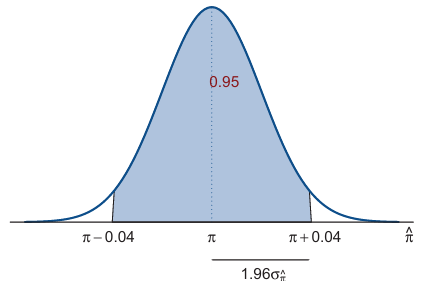

El problema ahora es que esta expresión para $n$ incluye al parámetro desconocido $\pi$. Sin embargo, podemos obtener un estimado inicial considerando el peor escenario posible, $\pi=0.5$.
$$
    n = \frac{(1.96)^2\pi(1-\pi)}{(0.04)^2}=600\text{,}
    $$
aún cuando este es un número bastante grande, nos asegura que con un nivel de confianza $0.95$, el margen de error no será mayor a $0.04$ sin importar el valor de $\pi$.

Sin embargo, si $\pi$ fuera menor a 0.5 (como intuitivamente esperaríamos que ocurriera), este número es muy grande. Dado que sobreestimando $\pi$ es mejor que subestimarlo, si consideramos $\pi=0.2$ obtenemos
$$
    n = \frac{(1.96)^2\pi(1-\pi)}{(0.04)^2}\approx 384\text{.}
    $$


## Intervalos de confianza para medias de poblaciones normales.
Como sabemos, cuando se muestrea ade una distribución mormal
$$
    Z = \frac{\bar{Y}-\mu}{S/\sqrt{n}}
$$
tiene una distribución normal estándar _exacta_, para todo $n$. Pero dado que $\sigma$ es casi siempre un error desconocido, sustituimos la desviación estándar _**muestral**_ $s$, en lugar de $\sigma$.

### La distribución $t$ de Student.
Sustituyendo $s$ en lugar de $\sigma$ para obtener el error estándar _estimado_ para $\bar{Y}$, $se=s/\sqrt{n}$, introduce un error extra. Para observaciones independientes de una distribución normal, con $S$ la raíz cuadrada de la varianza muestral tenemos que la cantidad pivotal
$$
    T = \frac{\bar{T}-\mu}{S/\sqrt{n}}
$$
tiene una distribución muestral sobre $\mathbb{R}$ que es ligeramente más dispersa que la distribución normal estándar. A esta distribución se le conoce como distribución $t$ (de Student).

- Tiene forma de campana y es simétrica alrededor de 0.
- $f(y)\propto1/[1+(y^2/d)]^{(d+1)/2}$, con $d$ un índice llamado _grados de libertad_. Para inferencia sobre una sola media poblacional tenemos que $d=n-1$. Con $d>2$ el valor esperado es 0 y $\sigma=\sqrt{\frac{d}{d-2}}$.
- Esta distr. tiene colas más pesadas que la N$(0,1)$ (decae más lento, hay más probabilidad para valores más grandes). Diferentes cuantiles score para la distr. $t$ aplican para diferentes grados de libertad. A mayor grados de libertad esta aproximación se asemeja más a la normal estándar.
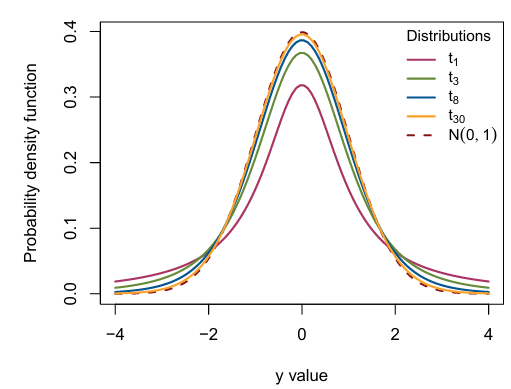

> ### Intervalo de confianza para media poblacional $\mu$
> 
> Para $n$ observaciones independientes de una población normal con media muestral $\bar{y}$, un intervalo de $100(1-\alpha)\%$ de confianza para $\mu$ es
> $$
 \bar{y}\pm t_{\alpha/2,n-1}\left(\frac{s}{\sqrt{n}}\right)
 $$
> donde $t_{\alpha/2, n-1}$ denota el cuantil $t$ de $n-1$ grados de libertad con probabilidad de cola $\alpha/2$.

## Ejercicio: Estimar cambio promedio de peso en mujeres con anorexia. 
Un estudio experimental comparó 3 terapias para mujeres jóvenes que sufren de anorexia. Para cada una el peso fue medido antes y después de un período fijo de tratamiento diseñado para ayudar a ganar peso. 
- Descarga los datos de https://stat4ds.rwth-aachen.de/data/Anorexia.dat
- Calcula la diferencia de peso después del período de tratamiento
- Enfócate únicamente en los datos de terapia cognitivo conductual ("cb" en la base de datos)
- Calcula un intervalo del $95\%$ de confianza para la media poblacional $\mu$ suponiendo que los datos se distribuyen normal.
- ¿Qué es lo que observas?
- Calcula ahora un intervalo del $99\%$ de confianza y compáralo con el anterior. Explica lo que encuentras.
- Realiza un histograma de la diferencia de peso en el caso cognitivo conductual. ¿Qué es lo que encuentras?
- Finalmente calcula un intervalo de confianza bootstrap para los datos y compáralo con los dos intervalos anteriores.